# 🚀 Practice Day 27

**📅 Date:** 2026-10-07  
📁 Category: Phase 4 · 캡스톤1(고객 세분화 RFM) (Round 2/3)

---
# 🎯 Today's Goal
*What am I trying to solve today?*

- Segment customers using RFM (Recency, Frequency, Monetary) — the same framework real BAs use to decide who to win back and who to reward
  (RFM(Recency·Frequency·Monetary)으로 고객을 세분화하기 — 실제 BA가 누구를 리텐션하고 누구에게 보상할지 결정할 때 쓰는 방식)
- Design and defend your own segment definitions, then see how much revenue each segment actually accounts for
  (직접 세그먼트 기준을 설계하고, 각 세그먼트가 실제로 매출에서 차지하는 비중까지 확인하기)

---
# 📂 Dataset

**Dataset Name:** Chapter & Verse 온라인 서점 — 고객·구매이력 (2테이블) / Chapter & Verse Online Bookstore — Customers & Transactions (2 tables)

**Source:** Synthetically generated for practice / 실습을 위해 코드로 생성한 가상 데이터

**Description:** Two tables: `customers` (50 rows: customer_id, join_date) and `transactions` (278 rows: transaction_id, customer_id → links to customers, purchase_date, amount in USD). Covers one year (2024) of purchase activity. Clean — no missing values or duplicates. Customers vary widely in how often, how recently, and how much they buy, making this a good fit for RFM segmentation. Use **2025-01-05** as \"today\" when computing Recency.
(`customers`(50명: customer_id, join_date)와 `transactions`(278건: transaction_id, customer_id(customers와 연결), purchase_date, amount(USD)) 2개 테이블입니다. 2024년 한 해 동안의 구매 기록이며, 결측치·중복 없이 깨끗합니다. 고객마다 구매 빈도·최근성·구매액이 크게 다르도록 설계되어 있어 RFM 세분화에 적합합니다. Recency 계산 시 **2025-01-05**를 기준일로 사용하세요.)

## Dataset Preview

In [48]:
# Dataset Preview
import pandas as pd
import numpy as np
from IPython.display import display

np.random.seed(42)
rng = np.random.default_rng(42)

# --- customers and their purchase transactions over 2024 ---
n_customers = 50
customer_ids = [f'C{str(i).zfill(3)}' for i in range(1, n_customers + 1)]

archetypes = rng.choice(
    ['Champion', 'Loyal', 'AtRisk', 'New', 'Lost'],
    size=n_customers,
    p=[0.14, 0.24, 0.20, 0.16, 0.26]
)

year_start = pd.to_datetime('2024-01-01')

rows = []
tx_counter = 1
for cid, arche in zip(customer_ids, archetypes):
    if arche == 'Champion':
        n_tx = rng.integers(9, 17)
        days = sorted(rng.choice(range(0, 365), size=n_tx - 1, replace=False)) + [rng.integers(360, 370)]
        amt_range = (35, 90)
    elif arche == 'Loyal':
        n_tx = rng.integers(5, 11)
        days = sorted(rng.choice(range(0, 365), size=n_tx, replace=False))
        amt_range = (20, 55)
    elif arche == 'AtRisk':
        n_tx = rng.integers(6, 12)
        days = sorted(rng.choice(range(0, 200), size=n_tx, replace=False))
        amt_range = (25, 60)
    elif arche == 'New':
        n_tx = rng.integers(1, 4)
        days = sorted(rng.choice(range(330, 370), size=n_tx, replace=False))
        amt_range = (15, 45)
    else:  # Lost
        n_tx = rng.integers(1, 3)
        days = sorted(rng.choice(range(0, 150), size=n_tx, replace=False))
        amt_range = (10, 35)

    for d in days:
        pdate = year_start + pd.Timedelta(days=int(d))
        amt = int(round(rng.uniform(*amt_range)))
        rows.append({'transaction_id': f'T{str(tx_counter).zfill(4)}', 'customer_id': cid,
                     'purchase_date': pdate, 'amount': amt})
        tx_counter += 1

transactions = pd.DataFrame(rows).sort_values('purchase_date').reset_index(drop=True)

customers = pd.DataFrame({
    'customer_id': customer_ids,
    'join_date': [year_start - pd.Timedelta(days=int(rng.integers(30, 900))) for _ in customer_ids]
})

print("Customers:")
display(customers.head())
print("\nTransactions:")
display(transactions.head())


Customers:


,customer_id,join_date
0,C001,2022-09-10
1,C002,2022-03-15
2,C003,2023-03-30
3,C004,2021-08-17
4,C005,2022-06-08



Transactions:


,transaction_id,customer_id,purchase_date,amount
0,T0200,C037,2024-01-02,70
1,T0034,C007,2024-01-03,21
2,T0092,C018,2024-01-03,83
3,T0184,C035,2024-01-03,53
4,T0119,C026,2024-01-03,22


## Dataset Information

In [49]:
# Dataset Information
print("Customers:", customers.shape)
customers.info()
print("\nTransactions:", transactions.shape)
transactions.info()

print("\n--- Describe: Customers ---")
display(customers.describe(include='all'))
print("\n--- Describe: Transactions ---")
display(transactions.describe(include='all'))


Customers: (50, 2)
<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   customer_id  50 non-null     str           
 1   join_date    50 non-null     datetime64[us]
dtypes: datetime64[us](1), str(1)
memory usage: 932.0 bytes

Transactions: (278, 4)
<class 'pandas.DataFrame'>
RangeIndex: 278 entries, 0 to 277
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   transaction_id  278 non-null    str           
 1   customer_id     278 non-null    str           
 2   purchase_date   278 non-null    datetime64[us]
 3   amount          278 non-null    int64         
dtypes: datetime64[us](1), int64(1), str(2)
memory usage: 8.8 KB

--- Describe: Customers ---


,customer_id,join_date
count,50,50
unique,50,NaN
top,C001,NaN
freq,1,NaN
mean,NaN,2022-08-04 23:02:24
min,NaN,2021-07-28 00:00:00
25%,NaN,2021-12-31 12:00:00
50%,NaN,2022-07-08 12:00:00
75%,NaN,2023-03-12 06:00:00
max,NaN,2023-11-28 00:00:00



--- Describe: Transactions ---


,transaction_id,customer_id,purchase_date,amount
count,278,278,278,278.000000
unique,278,50,NaN,NaN
top,T0200,C005,NaN,NaN
freq,1,16,NaN,NaN
mean,NaN,NaN,2024-06-03 18:49:12.517985,45.316547
min,NaN,NaN,2024-01-02 00:00:00,12.000000
25%,NaN,NaN,2024-03-01 06:00:00,32.000000
50%,NaN,NaN,2024-05-21 00:00:00,43.000000
75%,NaN,NaN,2024-08-15 18:00:00,54.750000
max,NaN,NaN,2025-01-04 00:00:00,89.000000


---
# ❓ Business Questions

1. **(Analysis)** For each customer, what are their Recency (days since last purchase), Frequency (number of transactions), and Monetary (total amount spent) values?
   (고객별 Recency·Frequency·Monetary 값은 각각 얼마인가?)
2. **(Analysis)** Using those RFM values, how would you classify customers into segments (e.g., Champions, Loyal, At Risk, Lost), and how many customers fall into each?
   (RFM 값을 기준으로 고객을 세그먼트로 분류하면(예: Champions/Loyal/At Risk/Lost), 각 세그먼트에는 몇 명이 속하는가?)
3. **(Analysis)** What share of total revenue does each segment account for?
   (각 세그먼트는 전체 매출의 몇 %를 차지하는가?)
4. **(Visualization)** Compare the number of customers across segments.
   (세그먼트별 고객 수를 비교하면?)
5. **(Visualization)** Show each segment's share of total revenue.
   (세그먼트별 매출 비중을 보면?)

---
# 🛠 Skills Used
- [ ] Python
- [ ] NumPy
- [ ] Pandas
- [ ] SQL
- [ ] Matplotlib
- [ ] Other: 

---
# 🔍 Data Cleaning Check

Things I checked:
- [ ] Missing Values
- [ ] Duplicate Rows
- [ ] Wrong Data Types
- [ ] Rename Columns
- [ ] Drop Columns


In [50]:
# Data Cleaning Check — inspect only. Fixes are in Q1–Q3.
# (확인만. 수정은 Q1~Q3)

print("===== transactions =====")
print("Missing values")
print(transactions.isnull().sum())
print("\nDuplicate rows:", transactions.duplicated().sum())
print("\nDtypes")
print(transactions.dtypes)
print("\nColumn names")
print(transactions.columns.tolist())
obj_cols = transactions.select_dtypes(include=["object", "string"]).columns
print("\nText columns — unique counts")
print(transactions[obj_cols].nunique())
print()

print("===== customers =====")
print("Missing values")
print(customers.isnull().sum())
print("\nDuplicate rows:", customers.duplicated().sum())
print("\nDtypes")
print(customers.dtypes)
print("\nColumn names")
print(customers.columns.tolist())
obj_cols = customers.select_dtypes(include=["object", "string"]).columns
print("\nText columns — unique counts")
print(customers[obj_cols].nunique())
print()


===== transactions =====
Missing values
transaction_id    0
customer_id       0
purchase_date     0
amount            0
dtype: int64

Duplicate rows: 0

Dtypes
transaction_id               str
customer_id                  str
purchase_date     datetime64[us]
amount                     int64
dtype: object

Column names
['transaction_id', 'customer_id', 'purchase_date', 'amount']

Text columns — unique counts
transaction_id    278
customer_id        50
dtype: int64

===== customers =====
Missing values
customer_id    0
join_date      0
dtype: int64

Duplicate rows: 0

Dtypes
customer_id               str
join_date      datetime64[us]
dtype: object

Column names
['customer_id', 'join_date']

Text columns — unique counts
customer_id    50
dtype: int64



---
# 📊 Analysis

## Question 1

**Question:** For each customer, what are their Recency, Frequency, and Monetary values? (고객별 R/F/M 값은?)

**Result:** Across 50 customers, Recency ranges **1–336** days, Frequency **1–16** transactions, Monetary **$17–$1,013**. Medians are **172** days, **5** transactions, **$172**.
(50명 고객 중 Recency는 1~336일, Frequency는 1~16건, Monetary는 $17~$1,013. 중앙값은 각각 172일, 5건, $172)

**Insight:** The spread is wide on all three. Some customers bought once right at the start of the year and never came back (high recency, low frequency), while others bought over a dozen times.
(세 값 모두 범위가 넓음. 어떤 고객은 연초에 한 번 사고 다시 안 돌아왔고(recency 높음, frequency 낮음), 어떤 고객은 10번 넘게 구매)

In [51]:
# Question 1: compute Recency / Frequency / Monetary per customer
# Direction: group transactions by customer_id; Recency = days between 2025-01-05 and each
# customer's most recent purchase_date; Frequency = transaction count; Monetary = amount sum

merged_df = pd.merge(transactions, customers, on='customer_id', how='left')

REFERENCE_DATE = pd.to_datetime('2025-01-05')

user_behavior = merged_df.groupby('customer_id').agg(
    recency=('purchase_date', lambda x: (REFERENCE_DATE - x.max()).days),
    frequency=('transaction_id', 'nunique'),
    monetary=('amount', 'sum')
).reset_index().sort_values('recency')

user_behavior

,customer_id,recency,frequency,monetary
8,C009,1,14,860
17,C018,3,14,870
4,C005,4,16,1013
19,C020,4,1,43
36,C037,5,13,840
49,C050,6,11,730
48,C049,6,2,61
3,C004,7,3,106
27,C028,8,14,942
42,C043,10,1,34


## Question 2

**Question:** Using those RFM values, how would you classify customers into segments, and how many fall into each? (RFM 기준 세그먼트 분류와 세그먼트별 인원은?)

**Result:** Lost **17**, New **10**, Loyal **8**, At Risk **8**, Champions **7**.
(Lost 17명, New 10명, Loyal 8명, At Risk 8명, Champions 7명)

**Insight:** Lost is the largest group at over a third of all customers. Champions is the smallest, but Question 3 shows revenue doesn't follow the same order.
(Lost가 전체의 1/3 넘게 가장 많음. Champions는 가장 적지만, Question 3을 보면 매출 순서는 이와 다름)

In [52]:
# Question 2: define your own segment rule from R/F/M and classify each customer
# thresholds on Recency/Frequency/Monetary to define segments like Champions/Loyal/At Risk/Lost

user_behavior['R'] = pd.qcut(user_behavior['recency'], q=4, labels=[4,3,2,1]).astype(int)
user_behavior['F'] = pd.qcut(user_behavior['frequency'], q=4, labels=[1,2,3,4]).astype(int)
user_behavior['M'] = pd.qcut(user_behavior['monetary'], q=4, labels=[1,2,3,4]).astype(int)

display(user_behavior.head(5))

conditions = [
    (user_behavior['R'] == 4) & (user_behavior['F'] > 2),  # Champions: very recent, frequent
    (user_behavior['R'] == 3) & (user_behavior['F'] > 2),  # Loyal: fairly recent, frequent
    (user_behavior['R'] < 3) & (user_behavior['F'] > 2),   # At Risk: used to buy often, gone quiet
    (user_behavior['R'] > 2) & (user_behavior['F'] < 3),   # New: recent, few orders
    (user_behavior['R'] < 3) & (user_behavior['F'] < 3),   # Lost: not recent, few orders
]
names = ['Champions', 'Loyal', 'At Risk', 'New', 'Lost']

user_behavior['segment'] = np.select(conditions, names, default='Unknown')

segment_counts = user_behavior['segment'].value_counts()
segment_counts

,customer_id,recency,frequency,monetary,R,F,M
8,C009,1,14,860,4,4,4
17,C018,3,14,870,4,4,4
4,C005,4,16,1013,4,4,4
19,C020,4,1,43,4,1,1
36,C037,5,13,840,4,4,4


segment
Lost         17
New          10
Loyal         8
At Risk       8
Champions     7
Name: count, dtype: int64

## Question 3

**Question:** What share of total revenue does each segment account for? (세그먼트별 매출 비중은?)

**Result:** Champions **43.3%**, At Risk **24.5%**, Loyal **19.0%**, New **8.1%**, Lost **5.1%**.
(Champions 43.3%, At Risk 24.5%, Loyal 19.0%, New 8.1%, Lost 5.1%)

**Insight:** Champions are only **7** of 50 customers but bring in **43.3%** of revenue — the opposite order from Question 2's headcount. Lost has the most customers (**17**) but only **5.1%** of revenue.
(Champions는 50명 중 7명뿐인데 매출의 43.3%를 차지함 — Question 2의 인원 순서와 반대. Lost는 인원이 가장 많지만(17명) 매출은 5.1%뿐)

In [53]:
# Question 3: total revenue share by segment
# Direction: group your RFM+segment table by segment and sum Monetary, then convert to % of total

revenue_share_by_segment = (user_behavior.groupby('segment')['monetary'].sum() / user_behavior['monetary'].sum() * 100).sort_values(ascending=False)
revenue_share_by_segment


segment
Champions    43.324337
At Risk      24.456263
Loyal        18.971265
New           8.136212
Lost          5.111923
Name: monetary, dtype: float64

---
# 📈 Visualization

**Chart 1:** Bar chart — customer count by segment (막대그래프: 세그먼트별 고객 수)

*Interpretation:* Lost is the tallest bar at **17**, followed by New (**10**). Champions is the shortest at **7**.
(Lost가 가장 높은 막대(17명), 그다음 New(10명). Champions가 가장 낮음(7명))

---

**Chart 2:** Pie chart — revenue share by segment (파이차트: 세그먼트별 매출 비중)

*Interpretation:* Champions takes the biggest slice at **43.3%**, almost half the pie, even though its wedge in Chart 1 (customer count) was the smallest.
(Champions가 파이에서 가장 큰 조각(43.3%)으로 거의 절반인데, Chart 1에서는 가장 작은 막대였음)

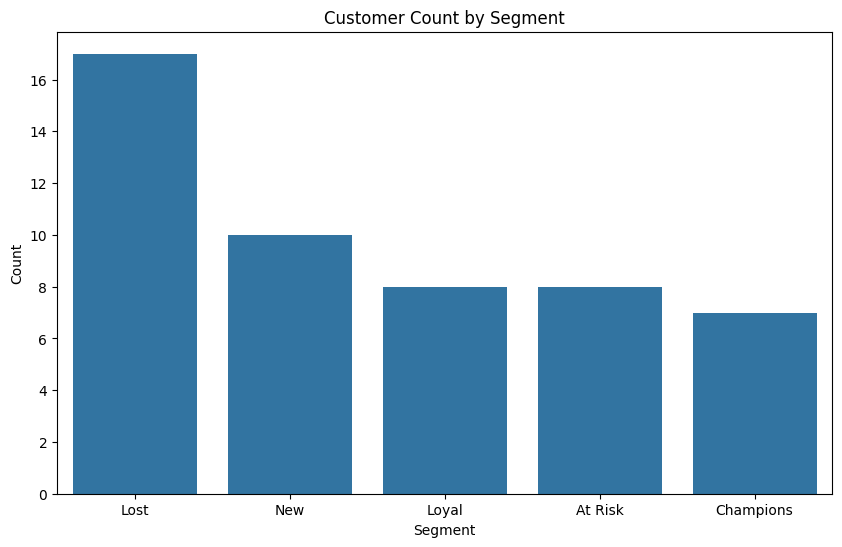

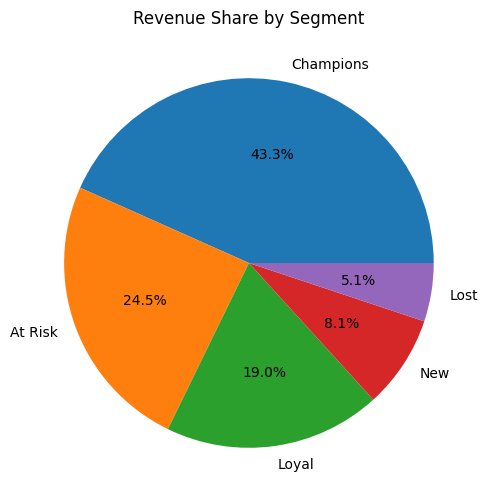

In [54]:
# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Chart 1: customer count by segment (bar)
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=segment_counts.index, y=segment_counts.values, ax=ax)
ax.set_title('Customer Count by Segment')
ax.set_xlabel('Segment')
ax.set_ylabel('Count')
plt.show()

# Chart 2: revenue share by segment (pie or bar)
fig, ax = plt.subplots(figsize=(10, 6))
ax.pie(x=revenue_share_by_segment.values, labels=revenue_share_by_segment.index, autopct='%1.1f%%')
ax.set_title('Revenue Share by Segment')
plt.show()


---
# 💼 Business Insights
*What did I discover?*

- Champions are only **7** of 50 customers but bring in **43.3%** of revenue.
  (Champions는 50명 중 7명뿐인데 매출의 43.3%를 차지)
- Lost is the largest segment by headcount (**17**, 34%) but the smallest by revenue (**5.1%**).
  (Lost는 인원 기준 가장 큰 세그먼트(17명, 34%)지만 매출 기준으론 가장 작음(5.1%))
- Customer count order and revenue order are opposite — Champions ranks last by headcount but first by revenue.
  (인원 순서와 매출 순서가 반대. Champions는 인원으로는 꼴찌, 매출로는 1위)

---
# 🎯 Business Recommendation
*If I were the Business Analyst...*

1. Protect the Champions segment first — losing even one of these **7** customers risks a large share of the **43.3%** they generate.
   (Champions 7명을 가장 먼저 지키기. 이들이 매출의 43.3%를 내는 만큼 한 명만 잃어도 타격이 큼)
2. Don't size win-back campaigns by headcount alone — Lost has the most people (**17**) but the least revenue upside (**5.1%**).
   (헤드카운트만 보고 리텐션 캠페인 규모를 정하지 않기. Lost는 인원은 많지만 매출 기여는 가장 작음(5.1%))
3. Watch At Risk closely: they still hold **24.5%** of revenue, the second-highest share, so losing them would hurt more than their headcount (**8**) suggests.
   (At Risk를 주의 깊게 보기. 매출 비중 24.5%로 2위라서, 인원(8명)보다 훨씬 큰 타격이 될 수 있음)

---
# ❌ Mistakes
*What mistakes did I make today?*

- Chart 2 reused `segment_counts` (customer headcount) for a chart titled "Revenue Share". It needed the Question 3 result (`revenue_share_by_segment`), not the Question 2 one.
  (Chart 2가 "Revenue Share" 제목인데 Question 2의 segment_counts(인원수)를 그대로 썼음. Question 3 결과(revenue_share_by_segment)를 써야 했음)
- First tried `sns.barplot(x='segment', y='customer_id', ...)` for a count chart — `customer_id` is a string column, so there's nothing numeric to average per bar.
  (처음엔 customer_id로 barplot을 그렸는데, 문자열 열이라 평균 낼 숫자가 없어서 안 됨)

---
# ✅ What I Learned
*Today's biggest lesson*

- RFM segmentation usually scores each of R/F/M with `pd.qcut` first, then combines the scores into named segments with rules, a sum/lookup table, or clustering.
  (RFM 세분화는 보통 pd.qcut으로 R/F/M 각각 점수를 매긴 뒤, 규칙·합산표·군집 중 하나로 세그먼트 이름을 붙임)
- `sns.countplot` counts rows per category automatically; `sns.barplot` needs a column that can actually be aggregated (not an ID string).
  (countplot은 범주별 행 수를 자동으로 셈. barplot은 평균 낼 수 있는 숫자 열이 필요하고, ID 문자열은 안 됨)
- Headcount share and revenue share can point in opposite directions — a segment can be small in count but large in value, or the reverse.
  (인원 비중과 매출 비중은 반대로 갈 수 있음. 인원은 적어도 매출은 크거나, 그 반대일 수 있음)

---
# 🧠 Reflection

**What was difficult?**
Deciding how to turn R/F/M scores into named segments, and catching that Chart 2 was plotting the wrong number.
(R/F/M 점수를 세그먼트 이름으로 바꾸는 방법을 정하는 것, Chart 2가 잘못된 값을 그리고 있던 걸 잡아낸 것)

**Why?**
There's no single standard rule for combining three scores into segments. And `segment_counts` and `revenue_share_by_segment` are both indexed by segment, so swapping them doesn't raise an error — it just plots the wrong story.
(세 점수를 세그먼트로 합치는 데 정해진 규칙이 하나가 아님. segment_counts와 revenue_share_by_segment 둘 다 세그먼트로 인덱싱되어 있어서, 바꿔 써도 에러 없이 조용히 다른 이야기를 그림)

**How did I solve it?**
Used boolean conditions on R and F with `np.select` to assign segment names, then checked the counts summed to 50 with no `Unknown` leftover. Fixed Chart 2 by pointing it at the Question 3 output instead.
(R, F에 불린 조건을 걸어 np.select로 세그먼트 이름을 매기고, 합계가 50명이고 Unknown이 안 남는지 확인함. Chart 2는 Question 3 결과를 가리키도록 고침)

**What would I do differently next time?**
Name chart variables after what they hold (e.g. `segment_counts` vs `revenue_share_by_segment`) so a mismatch between a chart's title and its data is easier to spot.
(변수 이름을 담긴 내용대로 짓기(segment_counts vs revenue_share_by_segment). 그러면 차트 제목과 실제 데이터가 안 맞는 걸 더 쉽게 알아챌 수 있음)

---
# ⭐ Self Evaluation

**Understanding**
★★★★★★★☆☆☆
Computing R/F/M, scoring with qcut, and reading headcount vs revenue share are clear.
(R/F/M 계산, qcut 점수화, 인원 vs 매출 비중 읽기는 이해함)

**Confidence**
★★★★★★☆☆☆☆

**Difficulty**
★★★★★★★☆☆☆
Choosing the segment rule from scratch and catching the mismatched chart variable were the new parts.
(세그먼트 규칙을 직접 정하는 것, 차트 변수가 서로 바뀐 걸 잡아내는 것이 새로웠음)

---
# 📌 Tomorrow
*Tomorrow I will learn:*

- Practice Day 28 — Capstone 2: churn analysis (Round 2/5)
  (캡스톤 2 — 이탈 분석 복습)